# Exercise 2 –Data Structures and Algorithms

Name: David Alfonso Reyes

Student ID : 3598535

In [ ]:
#import necessary libraries
import pandas as pd
import geopandas as gpd
import numpy as np
import shapely
from tqdm.auto import tqdm

### 1 – Load the geojson with the points. The points correspond to the center (centroid) of the following cities: Amsterdam, Berlin, Paris, Madrid, and Rome. 

In [2]:
europe_cities_gdf=gpd.read_file(r'europe_cities.geojson').to_crs(epsg=32632)
europe_cities_gdf.head()

,ID_HDC_G0,QA2_1V,AREA,GCPNT_LAT,GCPNT_LON,CTR_MN_NM,XBRDR,UC_NM_MN,geometry
0,1005.0,1.0,29.0,16.244864,-61.533048,France,0.0,Les Abymes,POINT (-9072136.442 4605331.5)
1,1007.0,1.0,35.0,14.613211,-61.066468,France,0.0,Fort-de-France,POINT (-9239119.863 4190086.189)
2,1104.0,1.0,20.0,4.930559,-52.311243,France,0.0,Cayenne,POINT (-8129648.037 1138449.712)
3,1475.0,1.0,19.0,28.070072,-16.727884,Spain,0.0,Los Cristianos,POINT (-2075511.316 3389542.218)
4,1479.0,1.0,29.0,28.397775,-16.552902,Spain,0.0,Puerto de la Cruz,POINT (-2048689.933 3423732.336)


File contains 720 unique cities with their coordinates

### 2 – Compute the distances among each pair of cities, in km, and store it into a list. You can select a subset of cities, and/or compute for it all, if you think it’s feasible.

In [ ]:
distances = []
for i, row_i in europe_cities_gdf.iterrows():
    for j, row_j in europe_cities_gdf.iterrows():
        if j > i:
            dist = row_i.geometry.distance(row_j.geometry)/ 1000
            distances.append({
                "city1": row_i["UC_NM_MN"],
                "city2": row_j["UC_NM_MN"],
                "distance_m": dist})

only_distance= [i["distance_m"] for i in distances]
print(len(distances))

258840


We computed all unique pairwise distances between cities and stored them in distances. Since the data is in a metric projected CRS, the distance calculations are very fast.

### 3 – Sort the list with the distances using two different algorithms. Measure the execution
time (in miliseconds, not the Big O) of each and compare.

In [38]:
%%timeit -n 1 -r 1
def bubble_sort(list_to_sort):
    for i in tqdm(range(len(list_to_sort) - 1)):
        stop = False
        for j in range(len(list_to_sort) - 1 - i): 
            if list_to_sort[j] > list_to_sort[j+1]:
                list_to_sort[j], list_to_sort[j+1] = list_to_sort[j+1], list_to_sort[j]
                stop = True
        if not stop: 
            break
    return list_to_sort

bubble_sort(only_distance)

 80%|███████▉  | 206757/258839 [35:43<08:59, 96.46it/s]  

35min 43s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [45]:
%%timeit
def quick_sort(arr):
    if len(arr) <= 1:
        return arr
    else:
        pivot = arr[len(arr) // 2]
        left = [x for x in arr if x < pivot]
        middle = [x for x in arr if x == pivot]
        right = [x for x in arr if x > pivot]
        return quick_sort(left) + middle + quick_sort(right)
    
quick_sort(only_distance)

394 ms ± 11 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


Bubble_sort took 35 minutes to sort the distances while quick_sort took only 294 ms. Quick_sort is significantly faster.

### 4 – Using two different implementations of searching algorithms, measure thecomputational time (in miliseconds, not the Big O) of each of them to find a selected city into the list. 

In [60]:
unique_cities= list(set([i["city1"] for i in distances]))

def linear_search(cities_list, target):
    for i,x in enumerate(cities_list):
        if x == target:
            #print("Found target:", target, "at index", i)
            return True
    return False

def hash_search(cities_set, target):
    if target in set(cities_set):
        #print("Found target:", target)
        return True
    else:
        return False

In [75]:
%%timeit
linear_search(unique_cities, 'Puerto de la Cruz')

9.36 μs ± 92.3 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [76]:
%%timeit
hash_search(unique_cities, 'Puerto de la Cruz')

7.69 μs ± 53.4 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


The hash search is faster than the linear search, even including the set(cities_set) operation inside the function. In general the hash is much faster (O(1)) than the linear search (O(n)) for large datasets.

### 5 – Now, let’s make a test using a queue and a stack. Store the names of the cities intoboth structures, and compare the different ways of accessing it. You can use the following implementation to the data structures, or make your own (recommended for practicing). Try to make find a certain city on that, and measure the execution time. Compare both. 

In [63]:
from collections import deque
stack=[city for city in unique_cities] # create stack
deque_ = deque(unique_cities) # create queue

In [64]:
%%timeit
stack=[city for city in unique_cities]
stack.append('Bogota')   # push to stack
stack.pop()              # pop from stack (remove Bogota)
stack.pop(0) 

6.55 μs ± 42.3 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [65]:
%%timeit
index = stack.index('Gandia')

316 ns ± 8.29 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


In [66]:
%%timeit
deque_ = deque(unique_cities)
deque_.append('Bogota')   # push to queue
deque_.pop()    
deque_.popleft()          # delete next first element

2.5 μs ± 42.6 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [67]:
%%timeit
index = deque_.index('Gandia')

316 ns ± 1.48 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


Insert and delete operations are faster in stack than in queue, but searching for an element is equally fast in both.

### 6 –Using the list of cities, and the distances computed, let’s represent it into a connected graph where the edges contain the distances among pairs of cities. To represent the graph, you should select a subset of cities, and make a dictionary containing each connection, in the following format: Graph = { city a: {city b: distance (a, b)}, city c: distance(a,c) … }

In [68]:
#From the distances dictionary created before, we create a connected graph with all cities like the following: 
#Graph = {
#    "Paris": {"London": 340, "Berlin": 880},
#    "London": {"Paris": 340, "Berlin": 930},
#    ...
#}

def build_graph(distance_list):

    graph = {}

    for record in distance_list:
        city1 = record["city1"]
        city2 = record["city2"]
        dist = record["distance_m"]

        if city1 not in graph:
            graph[city1] = {}
        if city2 not in graph:
            graph[city2] = {}

        graph[city1][city2] = dist
        graph[city2][city1] = dist

    return graph


Graph = build_graph(distances)
Graph['Les Abymes']

{'Fort-de-France': 447.5624330335331,
 'Cayenne': 3592.7084107866935,
 'Los Cristianos': 7101.472151989148,
 'Puerto de la Cruz': 7122.146969120753,
 'Funchal': 7138.327206636719,
 'Santa Cruz de Tenerife': 7151.021041800979,
 'Las Palmas de Gran Canaria': 7239.355961936609,
 'Arinaga': 7237.729099891732,
 'Arrecife': 7438.009479714233,
 'Lisbon': 7984.114754743887,
 'Amora': 7992.745141268267,
 'Barreiro': 7998.0296410926785,
 'Setúbal': 8010.391595601348,
 'Póvoa de Varzim': 8086.256843715166,
 'Vigo': 8110.533382879962,
 'Porto': 8092.687171810575,
 'Coimbra': 8086.534762283663,
 'Braga': 8117.618776587992,
 'A Coruña': 8167.512964983764,
 'Ferrol': 8187.245094352323,
 'Galway': 8499.096991628006,
 'Ourense': 8184.028831452479,
 'Cork': 8473.999985107106,
 'Huelva': 8161.963057702397,
 'Badajoz': 8184.207127903743,
 'Cádiz': 8213.210728571847,
 'El Puerto de Santa María': 8216.67254026402,
 'Cáceres': 8247.911386559528,
 'San Fernando': 8218.426547383253,
 'Jerez': 8228.479745939992

### 7 – (extra, not mandatory) Plot that graph into a figure and see how it looks like. 

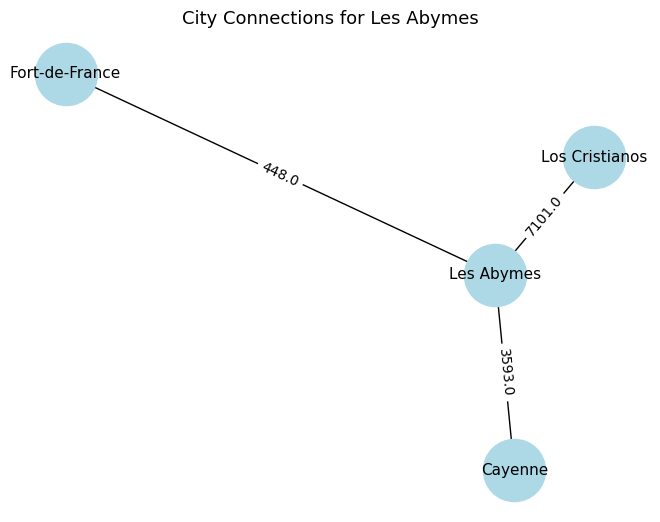

In [69]:
import networkx as nx
import matplotlib.pyplot as plt
main_city = 'Les Abymes'
neighbors = dict(list(Graph[main_city].items())[:3])

G = nx.Graph()

for neighbor, distance in neighbors.items():
    G.add_edge(main_city, neighbor, weight=round(distance, 0))

pos = nx.spring_layout(G, seed=1)
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000, font_size=11)
nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, 'weight'), font_size=10)
plt.title("City Connections for Les Abymes", fontsize=13)
plt.show()

### 8 – Finally, to understand how usefull KD-trees can be in geospatial algorithms, we will create a Kdtree for searching by the distance across the whole set of 720 cities. Select a few different cities, and compute the nearest neighbor. Check how many cities were checked until it found the nearest one. Measure also the computational time for that operation. For using the KD-tree, the package scipy.spatial provides a very efficient implementation: https://docs.scipy.org/doc/scipy/reference/spatial.html.

In [70]:
from scipy.spatial import KDTree

#Build the KD-tree
coords = europe_cities_gdf[['GCPNT_LAT', 'GCPNT_LON']].to_numpy() 
city_names = europe_cities_gdf['UC_NM_MN'].to_numpy()

tree = KDTree(coords)

def nearest_neighbor(city):

    point = coords[np.where(city_names == city)[0][0]]
    dist, nn_idx = tree.query(point, k=2)

    nearest_city = city_names[nn_idx[1]]
    distance = dist[1]

    return nearest_city

In [71]:
%%timeit
city = "Huelva" 
nn_city = nearest_neighbor(city)
#print(f"Nearest city to {city} is {nn_city}")

14.6 μs ± 107 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


The kd-tree implementaion of scipy.spatial does not provide a way to check how many nodes (cities) were checked during the search. 